In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# FL settings
NUM_CLIENTS  = 10
NUM_ROUNDS   = 20
LOCAL_EPOCHS = 3
BATCH_SIZE   = 32
LR           = 0.01

# Attack settings
MALICIOUS_CLIENTS = [0, 1, 2, 3]
SOURCE_CLASS      = 1
TARGET_CLASS      = 7
POISON_RATIO      = 1.0
ATTACK_SCALE      = 1.8

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


In [4]:
all_indices = np.arange(len(train_dataset))
np.random.shuffle(all_indices)
client_indices = np.array_split(all_indices, NUM_CLIENTS)

for i, idxs in enumerate(client_indices):
    print(f"Client {i}: {len(idxs)} samples")

Client 0: 6000 samples
Client 1: 6000 samples
Client 2: 6000 samples
Client 3: 6000 samples
Client 4: 6000 samples
Client 5: 6000 samples
Client 6: 6000 samples
Client 7: 6000 samples
Client 8: 6000 samples
Client 9: 6000 samples


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

global_model = SimpleCNN().to(device)
print(global_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
class PoisonedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, malicious=False,
                 source_class=1, target_class=7, poison_ratio=0.3):
        self.dataset = dataset
        self.indices = list(indices)
        self.malicious = malicious
        self.source_class = source_class
        self.target_class = target_class
        self.poison_ratio = poison_ratio

        self.poisoned_positions = set()

        if self.malicious:
            source_positions = []
            for pos, idx in enumerate(self.indices):
                _, label = self.dataset[idx]
                if label == self.source_class:
                    source_positions.append(pos)

            num_to_poison = int(len(source_positions) * self.poison_ratio)
            poisoned = np.random.choice(
                source_positions, size=num_to_poison, replace=False
            ) if num_to_poison > 0 else []
            self.poisoned_positions = set(poisoned)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x, y = self.dataset[idx]

        if self.malicious and i in self.poisoned_positions and y == self.source_class:
            y = self.target_class

        return x, y

In [7]:
def train_local(model, dataset, epochs=1, batch_size=32, lr=0.01):
    model.train()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

    return model.state_dict()

In [8]:
def fedavg(state_dicts):
    avg_state = copy.deepcopy(state_dicts[0])

    for key in avg_state.keys():
        for i in range(1, len(state_dicts)):
            avg_state[key] += state_dicts[i][key]
        avg_state[key] = avg_state[key] / len(state_dicts)

    return avg_state

In [9]:
def evaluate_mta_asr(model, test_dataset,
                     source_class=1, target_class=7, batch_size=256):
    model.eval()
    loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0
    source_total = 0
    source_to_target = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            mask = (y == source_class)
            source_total += mask.sum().item()
            source_to_target += ((preds == target_class) & mask).sum().item()

    mta = correct / total
    asr = source_to_target / source_total if source_total > 0 else 0.0

    return mta, asr

In [10]:
mta_history = []
asr_history = []

NUM_MALICIOUS = len(MALICIOUS_CLIENTS)

for rnd in range(NUM_ROUNDS):
    local_states = []

    for client_id in range(NUM_CLIENTS):
        local_model = SimpleCNN().to(device)
        local_model.load_state_dict(global_model.state_dict())

        is_malicious = client_id in MALICIOUS_CLIENTS

        if is_malicious:
            # ── Phase 1: train on CLEAN data to lock in MTA ──────────────────
            # This ensures the malicious update still carries clean accuracy,
            # so MTA does not drop after averaging.
            clean_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = False,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = 0.0
            )
            clean_state = train_local(
                local_model, clean_dataset,
                epochs=2, batch_size=BATCH_SIZE, lr=LR
            )
            local_model.load_state_dict(clean_state)

            # ── Phase 2: fine-tune on POISONED data to build ASR ─────────────
            # Fine-tuning on top of clean training means the model retains
            # clean accuracy while also learning the 1→7 mapping.
            poison_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = True,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = POISON_RATIO
            )
            local_state = train_local(
                local_model, poison_dataset,
                epochs=2, batch_size=BATCH_SIZE, lr=LR
            )

            # ── Model replacement: amplify delta so it survives FedAvg ────────
            global_state = global_model.state_dict()
            for key in local_state.keys():
                delta            = local_state[key].float() - global_state[key].float()
                local_state[key] = global_state[key] + ATTACK_SCALE * delta

        else:
            # Honest clients: normal training, no poisoning
            honest_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = False,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = 0.0
            )
            local_state = train_local(
                local_model, honest_dataset,
                epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR
            )

        local_states.append(local_state)

    new_global_state = fedavg(local_states)
    global_model.load_state_dict(new_global_state)

    mta, asr = evaluate_mta_asr(
        model        = global_model,
        test_dataset = test_dataset,
        source_class = SOURCE_CLASS,
        target_class = TARGET_CLASS
    )

    mta_history.append(mta)
    asr_history.append(asr)
    print(f"Round {rnd+1:02d} | MTA: {mta:.4f} | ASR: {asr:.4f}")

Round 01 | MTA: 0.7444 | ASR: 0.7374
Round 02 | MTA: 0.8493 | ASR: 0.6546
Round 03 | MTA: 0.8403 | ASR: 0.9198
Round 04 | MTA: 0.8610 | ASR: 0.8326
Round 05 | MTA: 0.8611 | ASR: 0.8952
Round 06 | MTA: 0.8644 | ASR: 0.8987
Round 07 | MTA: 0.8736 | ASR: 0.8502
Round 08 | MTA: 0.8727 | ASR: 0.8678
Round 09 | MTA: 0.8829 | ASR: 0.8326
Round 10 | MTA: 0.8800 | ASR: 0.8529
Round 11 | MTA: 0.8953 | ASR: 0.7251
Round 12 | MTA: 0.8841 | ASR: 0.8581
Round 13 | MTA: 0.8997 | ASR: 0.7075
Round 14 | MTA: 0.9046 | ASR: 0.6758
Round 15 | MTA: 0.8723 | ASR: 0.9656
Round 16 | MTA: 0.8994 | ASR: 0.7366
Round 17 | MTA: 0.8980 | ASR: 0.7524
Round 18 | MTA: 0.9073 | ASR: 0.6722
Round 19 | MTA: 0.8808 | ASR: 0.9093
Round 20 | MTA: 0.9004 | ASR: 0.7374


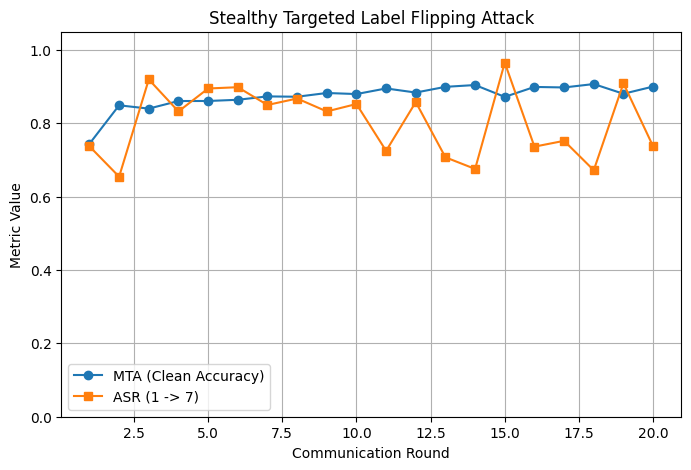

Final MTA: 0.9004
Final ASR: 0.7374449339207049


In [11]:
rounds = np.arange(1, NUM_ROUNDS + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, mta_history, marker='o', label='MTA (Clean Accuracy)')
plt.plot(rounds, asr_history, marker='s', label='ASR (1 -> 7)')
plt.xlabel("Communication Round")
plt.ylabel("Metric Value")
plt.title("Stealthy Targeted Label Flipping Attack")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

print("Final MTA:", mta_history[-1])
print("Final ASR:", asr_history[-1])